In [ ]:
#For downloading the dataset from Kaggle
!pip install opendatasets
import opendatasets as od

In [ ]:
# Downloading the Dataset to the root directory
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
dataset_url = "https://www.kaggle.com/datasets/prathumarikeri/indian-sign-language-isl/"
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: archisha05
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/prathumarikeri/indian-sign-language-isl


100%|██████████| 281M/281M [00:02<00:00, 120MB/s] 


In [ ]:
from os import listdir

In [ ]:
!ls -lh


total 83M
drwxr-xr-x 3 root root 4.0K Feb 14 15:50 indian-sign-language-isl
-rw-r--r-- 1 root root  82M Feb 14 15:56 ISL_Dataset.zip
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data


In [ ]:
!file ISL_Dataset.zip


ISL_Dataset.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [ ]:
!ls

indian-sign-language-isl  ISL_Dataset.zip  sample_data


In [ ]:
!unzip ISL_Dataset.zip -d ISL

Streaming output truncated to the last 5000 lines.
  inflating: ISL/Indian/V/819.jpg    
  inflating: ISL/Indian/V/82.jpg     
  inflating: ISL/Indian/V/820.jpg    
  inflating: ISL/Indian/V/821.jpg    
  inflating: ISL/Indian/V/822.jpg    
  inflating: ISL/Indian/V/823.jpg    
  inflating: ISL/Indian/V/824.jpg    
  inflating: ISL/Indian/V/825.jpg    
  inflating: ISL/Indian/V/826.jpg    
  inflating: ISL/Indian/V/827.jpg    
  inflating: ISL/Indian/V/828.jpg    
  inflating: ISL/Indian/V/829.jpg    
  inflating: ISL/Indian/V/83.jpg     
  inflating: ISL/Indian/V/830.jpg    
  inflating: ISL/Indian/V/831.jpg    
  inflating: ISL/Indian/V/832.jpg    
  inflating: ISL/Indian/V/833.jpg    
  inflating: ISL/Indian/V/834.jpg    
  inflating: ISL/Indian/V/835.jpg    
  inflating: ISL/Indian/V/836.jpg    
  inflating: ISL/Indian/V/837.jpg    
  inflating: ISL/Indian/V/838.jpg    
  inflating: ISL/Indian/V/839.jpg    
  inflating: ISL/Indian/V/84.jpg     
  inflating: ISL/Indian/V/840.jpg    

In [ ]:
total_signs=sorted(listdir("/content/ISL/Indian"))
print(total_signs)

['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [ ]:
import tensorflow as tf
from tensorflow import keras


In [ ]:
print(tf.__version__)


2.19.0


In [ ]:
# Important imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import cv2
import random
from os import listdir
from sklearn.preprocessing import  LabelBinarizer
from keras.preprocessing import image
from tensorflow.keras.utils import img_to_array
from tensorflow.keras.optimizers import Adam

from PIL import Image
from keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, LeakyReLU
from sklearn.model_selection import train_test_split

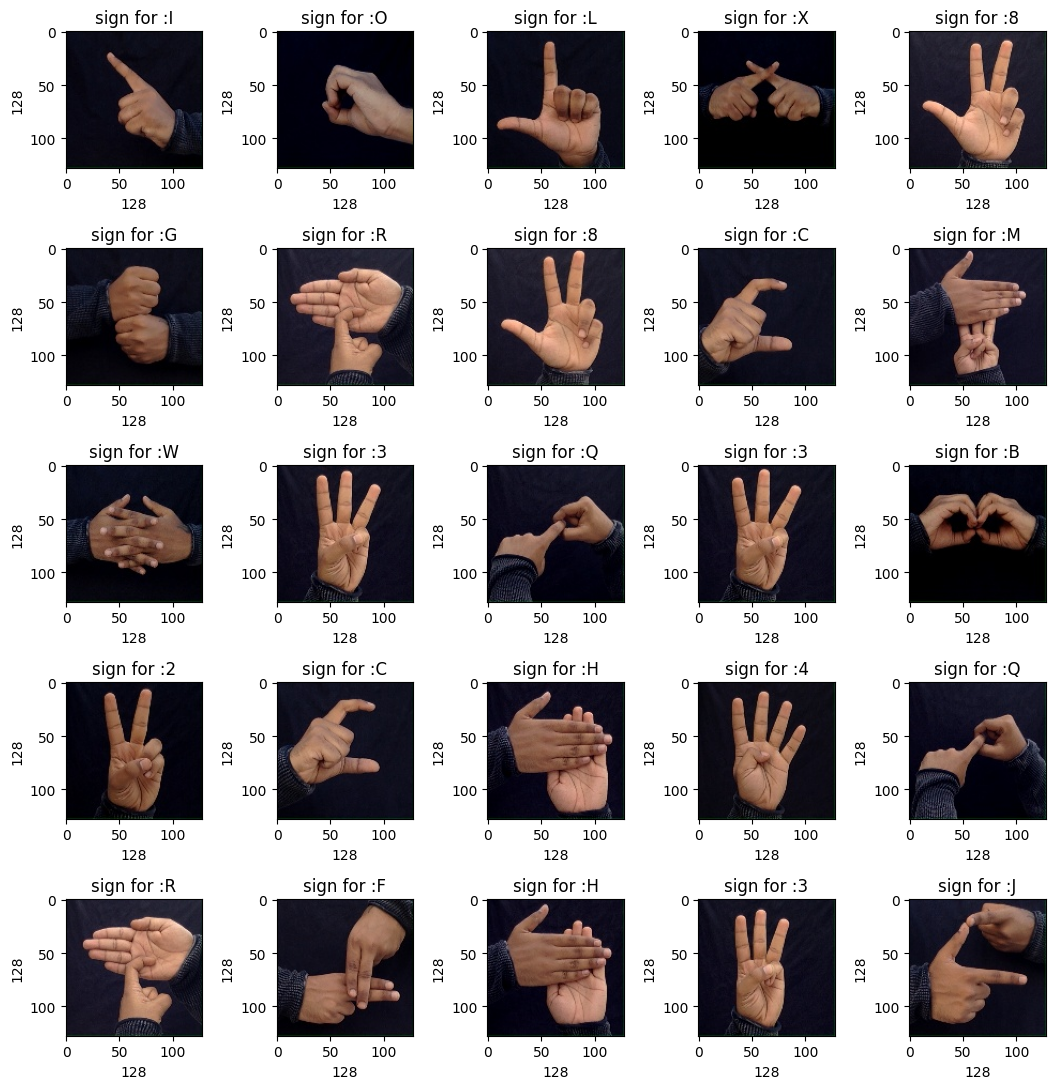

In [ ]:
# Plotting some random images in the dataset
# Plotting 25 images to check dataset
plt.figure(figsize=(11,11))
path = "/content/ISL/Indian"
for i in range(1,26):
    plt.subplot(5,5,i)
    plt.tight_layout()
    directry=random.choice(total_signs)
    rand_img = imread(path +'/'+ directry+'/'+random.choice(sorted(listdir(path+'/'+directry+'/'))))
    plt.imshow(rand_img)
    plt.title('sign for :'+directry)
    plt.xlabel(rand_img.shape[1], fontsize = 10)
    plt.ylabel(rand_img.shape[0], fontsize = 10)

In [ ]:
dir1 = "/content/ISL/Indian"
root_dir = listdir(dir1)
image_list, label_list = [], []
print(root_dir)

['N', 'R', '5', 'J', 'T', 'X', '9', 'S', 'Z', '4', 'G', 'F', '6', 'H', '3', 'M', '2', 'Y', 'L', '7', 'A', 'W', 'Q', 'O', 'D', 'E', '1', 'K', 'B', 'C', '8', 'U', 'V', 'P', 'I']


In [ ]:
# Resizing Each image and appending them to an Image list and their directory name to the label list
for directory in root_dir:
    i=0
    for files in listdir(f"{dir1}/{directory}"):
        image_path = f"{dir1}/{directory}/{files}"
        image = Image.open(image_path)
        image = image.resize((50,50))
        image = img_to_array(image)
        image_list.append(image)
        i+=1
        label_list.append(directory)
        if i>3000:
          break

NameError: name 'root_dir' is not defined

In [21]:
from os import listdir
from PIL import Image
from tensorflow.keras.utils import img_to_array
import os

image_list = []
label_list = []

dir1 = "/content/ISL/Indian"
root_dir = sorted(listdir(dir1))

for directory in root_dir:
    i = 0
    folder_path = os.path.join(dir1, directory)

    for file in listdir(folder_path):
        image_path = os.path.join(folder_path, file)

        if os.path.isfile(image_path):   # Important safety check
            try:
                image = Image.open(image_path)
                image = image.resize((50, 50))
                image = img_to_array(image)

                image_list.append(image)
                label_list.append(directory)

                i += 1
                if i > 3000:
                    break
            except:
                pass  # Skip corrupted images

In [22]:
# Visualize the number of classes count
print(directory)
label_counts = pd.DataFrame(label_list).value_counts()
sorted(label_counts)

Z


[1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1200,
 1290,
 1379,
 1429,
 1447]

In [23]:
num_classes = len(label_counts)
num_classes

35

In [24]:
np.array(image_list).shape

(42745, 50, 50, 3)

In [25]:
label_list = np.array(label_list)
label_list.shape

(42745,)

In [27]:
# Splitting the lists as 80% Train and 20% Test
x_train, x_test, y_train, y_test = train_test_split(image_list, label_list, test_size=0.2, random_state = 10)

In [28]:
x_train = np.array(x_train, dtype=np.float16) / 255.0
x_test = np.array(x_test, dtype=np.float16) / 255.0
x_train = x_train.reshape( -1, 50,50,3)
x_test = x_test.reshape( -1, 50,50,3)

In [29]:
lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.fit_transform(y_test)
print(lb.classes_)

['1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I'
 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [30]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2)

In [31]:
print(y_train.shape)
print(x_train.shape)

(27356, 35)
(27356, 50, 50, 3)


In [ ]:
#Creating a CNN model and printing the model summary